# **1: Introduction and Setup**

In [1]:
# -*- coding: utf-8 -*-
"""xai_b3.ipynb

# Explainable AI (XAI) for Multimodal Federated Learning Diabetes Detection

**Using EfficientNet-B3 @ 300×300**

This notebook implements:
- **SHAP explanations** for the EHR branch (feature importance)
- **Grad-CAM visualizations** for the Retinal branch (saliency maps on B3)

Prerequisites:
- Trained global FL model: `global_multimodal_fl_b3.pth`
- Trained EHR model: `mlp_ehr_binary_diabetes.pth`
- Trained Retinal model: `efficientnet_b3_binary_dr_twostage.pth`

Author: [Your Name]
Date: 2025
Project: Multimodal Federated Learning for Diabetes Detection
"""

'xai_b3.ipynb\n\n# Explainable AI (XAI) for Multimodal Federated Learning Diabetes Detection\n\n**Using EfficientNet-B3 @ 300×300**\n\nThis notebook implements:\n- **SHAP explanations** for the EHR branch (feature importance)\n- **Grad-CAM visualizations** for the Retinal branch (saliency maps on B3)\n\nPrerequisites:\n- Trained global FL model: `global_multimodal_fl_b3.pth`\n- Trained EHR model: `mlp_ehr_binary_diabetes.pth`\n- Trained Retinal model: `efficientnet_b3_binary_dr_twostage.pth`\n\nAuthor: [Your Name]  \nDate: 2025  \nProject: Multimodal Federated Learning for Diabetes Detection  \n'

# **2: Install Required Packages**

In [2]:
# Install packages with compatible versions
!pip install shap==0.44.1 -q  # Compatible with numpy 1.x
!pip install torchcam -q
!pip install captum -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 56.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 93.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
op

# **3: Import Libraries**

In [1]:
import os
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import models, transforms
from torchvision.transforms.functional import to_pil_image
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from tqdm import tqdm
import warnings

# SHAP
import shap

# Grad-CAM
from torchcam.methods import GradCAM, GradCAMpp, SmoothGradCAMpp
from torchcam.utils import overlay_mask

warnings.filterwarnings('ignore')
shap.initjs()

print("=" * 70)
print("EXPLAINABLE AI (XAI) FOR MULTIMODAL FL")
print("Using EfficientNet-B3 @ 300×300")
print("=" * 70)

EXPLAINABLE AI (XAI) FOR MULTIMODAL FL
Using EfficientNet-B3 @ 300×300


# **4: Set Device and Random Seed**

In [2]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {device}")

# Set random seed
def seed_everything(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
print("Random seed set to 42")


Device: cuda
Random seed set to 42


# **5: Configuration**

In [3]:
class XAIConfig:
    """Configuration for XAI analysis."""

    # ─────────────────────────────────────────────────────────
    # Model paths — CHANGED to B3 paths
    # ─────────────────────────────────────────────────────────
    GLOBAL_MODEL_PATH = "/content/drive/MyDrive/MULTIMODAL/models/global_fl_b3_experiment/global_multimodal_fl_b3.pth"
    EHR_MODEL_PATH = "/content/drive/MyDrive/MULTIMODAL/models/mlp_ehr_binary_diabetes.pth"
    RETINAL_MODEL_PATH = "/content/drive/MyDrive/MULTIMODAL/models/efficientnet_b3_experiment/efficientnet_b3_binary_dr_twostage.pth"

    # ─────────────────────────────────────────────────────────
    # Data paths — CHANGED to B3 cache (300×300)
    # ─────────────────────────────────────────────────────────
    EHR_DATA_DIR = "/content/drive/MyDrive/MULTIMODAL/datasets/diabetes_prediction"
    RETINAL_SPLITS_DIR = "/content/drive/MyDrive/MULTIMODAL/datasets/EYEPACS/splits"
    RETINAL_CACHE_DIR = "/content/drive/MyDrive/MULTIMODAL/datasets/EYEPACS/preprocessed_cache_300"

    # ─────────────────────────────────────────────────────────
    # SHAP settings
    # ─────────────────────────────────────────────────────────
    SHAP_BACKGROUND_SAMPLES = 500   # Number of background samples
    SHAP_TEST_SAMPLES = 200         # Number of test samples to explain

    # ─────────────────────────────────────────────────────────
    # Grad-CAM settings — CHANGED image size to 300
    # ─────────────────────────────────────────────────────────
    GRADCAM_NUM_EXAMPLES = 12       # Number of examples to visualize
    IMAGE_SIZE = 300                # B3 native resolution

    # ─────────────────────────────────────────────────────────
    # Save paths — CHANGED to B3 experiment directory
    # ─────────────────────────────────────────────────────────
    SAVE_DIR = "/content/drive/MyDrive/MULTIMODAL/xai_results_b3"

    # ImageNet normalization (used during training)
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD = [0.229, 0.224, 0.225]


config = XAIConfig()

# Create save directory
os.makedirs(config.SAVE_DIR, exist_ok=True)

print("\nXAI Configuration (EfficientNet-B3):")
print(f"  SHAP background samples: {config.SHAP_BACKGROUND_SAMPLES}")
print(f"  SHAP test samples: {config.SHAP_TEST_SAMPLES}")
print(f"  Grad-CAM examples: {config.GRADCAM_NUM_EXAMPLES}")
print(f"  Image size: {config.IMAGE_SIZE}×{config.IMAGE_SIZE}")
print(f"  Save directory: {config.SAVE_DIR}")


XAI Configuration (EfficientNet-B3):
  SHAP background samples: 500
  SHAP test samples: 200
  Grad-CAM examples: 12
  Image size: 300×300
  Save directory: /content/drive/MyDrive/MULTIMODAL/xai_results_b3


# **6: Define EHR Classifier Model**

In [4]:
class EHRClassifier(nn.Module):
    """MLP for EHR tabular data classification."""

    def __init__(self, n_features: int, hidden_dims: list = [128, 64, 32], dropout_rate: float = 0.3):
        super(EHRClassifier, self).__init__()
        self.n_features = n_features
        self.hidden_dims = hidden_dims

        layers = []
        in_dim = n_features
        for i, out_dim in enumerate(hidden_dims):
            layers.extend([
                nn.Linear(in_dim, out_dim),
                nn.BatchNorm1d(out_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate if i < len(hidden_dims) - 1 else dropout_rate * 0.5)
            ])
            in_dim = out_dim

        self.feature_extractor = nn.Sequential(*layers)
        self.feature_dim = hidden_dims[-1]
        self.classifier = nn.Sequential(nn.Linear(hidden_dims[-1], 1), nn.Sigmoid())

    def extract_features(self, x):
        return self.feature_extractor(x)

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.classifier(features)

print("✓ EHRClassifier defined")

✓ EHRClassifier defined


# **7: Define Retinal Classifier Model (EfficientNet-B3)**

In [5]:
class BinaryDRClassifier(nn.Module):
    """Binary DR Classifier using EfficientNet backbone."""

    def __init__(self, model_name='efficientnet_b3', pretrained=False, dropout=0.3):
        super().__init__()
        self.model_name = model_name

        if model_name == 'efficientnet_b0':
            self.backbone = models.efficientnet_b0(weights=None)
        elif model_name == 'efficientnet_b1':
            self.backbone = models.efficientnet_b1(weights=None)
        elif model_name == 'efficientnet_b2':
            self.backbone = models.efficientnet_b2(weights=None)
        elif model_name == 'efficientnet_b3':
            self.backbone = models.efficientnet_b3(weights=None)
        else:
            raise ValueError(f'Model {model_name} not supported.')

        n = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        self.feature_dim = n  # 1536 for B3

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(n, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, 1)
        )

    def extract_features(self, x):
        return self.backbone(x)

    def forward(self, x):
        f = self.backbone(x)
        return self.classifier(f)

print("✓ BinaryDRClassifier defined (supports B0/B1/B2/B3)")

✓ BinaryDRClassifier defined (supports B0/B1/B2/B3)


# **8: Define Global Multimodal Model**

In [6]:
class GlobalMultimodalModel(nn.Module):
    """Global model for Federated Learning with multimodal inputs."""

    def __init__(self, ehr_encoder, ret_encoder, ehr_dim, img_dim, classifier_hidden=256):
        super().__init__()

        self.ehr_encoder = ehr_encoder
        self.ret_encoder = ret_encoder
        self.ehr_dim = ehr_dim
        self.img_dim = img_dim
        self.combined_dim = ehr_dim + img_dim

        self.classifier = nn.Sequential(
            nn.Linear(self.combined_dim, classifier_hidden),
            nn.ReLU(),
            nn.BatchNorm1d(classifier_hidden),
            nn.Dropout(0.3),
            nn.Linear(classifier_hidden, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 1)
        )

    def forward_ehr(self, x_ehr):
        ehr_feats = self.ehr_encoder(x_ehr)
        img_zero = x_ehr.new_zeros(x_ehr.size(0), self.img_dim)
        fused = torch.cat([ehr_feats, img_zero], dim=1)
        return self.classifier(fused)

    def forward_retinal(self, x_img):
        img_feats = self.ret_encoder(x_img)
        ehr_zero = x_img.new_zeros(x_img.size(0), self.ehr_dim)
        fused = torch.cat([ehr_zero, img_feats], dim=1)
        return self.classifier(fused)

    def forward_combined(self, x_ehr, x_img):
        ehr_feats = self.ehr_encoder(x_ehr)
        img_feats = self.ret_encoder(x_img)
        fused = torch.cat([ehr_feats, img_feats], dim=1)
        return self.classifier(fused)

print("✓ GlobalMultimodalModel defined")

✓ GlobalMultimodalModel defined


# **9: Load EHR Model**

In [7]:
print("\n" + "=" * 60)
print("STEP 1: LOADING GLOBAL FL MODEL (B3)")
print("=" * 60)

print("\n[1/3] Loading EHR Model...")

ehr_checkpoint = torch.load(config.EHR_MODEL_PATH, map_location=device, weights_only=False)

ehr_model = EHRClassifier(
    n_features=ehr_checkpoint['n_features'],
    hidden_dims=ehr_checkpoint['hidden_dims'],
    dropout_rate=ehr_checkpoint.get('dropout_rate', 0.3)
)
ehr_model.load_state_dict(ehr_checkpoint['model_state_dict'])

ehr_dim = ehr_checkpoint['feature_dim']
FEATURE_NAMES = ehr_checkpoint['feature_names']
TARGET_COLUMN = ehr_checkpoint['preprocess_config']['target_column']

print(f"  ✓ EHR Model loaded")
print(f"    - Features: {FEATURE_NAMES}")
print(f"    - Feature dim: {ehr_dim}")


STEP 1: LOADING GLOBAL FL MODEL (B3)

[1/3] Loading EHR Model...
  ✓ EHR Model loaded
    - Features: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
    - Feature dim: 32


# **10: Load Retinal Model (EfficientNet-B3)**

In [8]:
print("\n[2/3] Loading Retinal Model (EfficientNet-B3)...")

ret_checkpoint = torch.load(config.RETINAL_MODEL_PATH, map_location=device, weights_only=False)

ret_config = ret_checkpoint.get('config', {})
retinal_model = BinaryDRClassifier(
    model_name=ret_config.get('model_name', 'efficientnet_b3'),
    pretrained=False,
    dropout=ret_config.get('dropout', 0.3)
)
retinal_model.load_state_dict(ret_checkpoint['model_state_dict'])

img_dim = ret_checkpoint['feature_dim']  # 1536 for B3

print(f"  ✓ Retinal Model loaded")
print(f"    - Model: {ret_config.get('model_name', 'efficientnet_b3')}")
print(f"    - Image size: {ret_config.get('image_size', 300)}")
print(f"    - Feature dim: {img_dim}")


[2/3] Loading Retinal Model (EfficientNet-B3)...
  ✓ Retinal Model loaded
    - Model: efficientnet_b3
    - Image size: 300
    - Feature dim: 1536


# **11: Build and Load Global FL Model**

In [9]:
print("\n[3/3] Loading Global FL Model (B3)...")

global_checkpoint = torch.load(config.GLOBAL_MODEL_PATH, map_location=device, weights_only=False)

# Create global model with encoders
global_model = GlobalMultimodalModel(
    ehr_encoder=ehr_model.feature_extractor,
    ret_encoder=retinal_model.backbone,
    ehr_dim=ehr_dim,
    img_dim=img_dim
).to(device)

# Load the FL-trained weights
global_model.load_state_dict(global_checkpoint['model_state_dict'])
global_model.eval()

print(f"  ✓ Global FL Model (B3) loaded")
print(f"    - EHR dim: {ehr_dim}")
print(f"    - Retinal dim: {img_dim}")
print(f"    - Combined: {ehr_dim + img_dim}")

# Get test results from checkpoint
if 'test_results' in global_checkpoint:
    test_results = global_checkpoint['test_results']
    print(f"\n  FL Test Results (from checkpoint):")
    print(f"    - EHR AUC: {test_results['ehr']['auc']:.4f}")
    print(f"    - Retinal AUC: {test_results['retinal']['auc']:.4f}")


[3/3] Loading Global FL Model (B3)...
  ✓ Global FL Model (B3) loaded
    - EHR dim: 32
    - Retinal dim: 1536
    - Combined: 1568

  FL Test Results (from checkpoint):
    - EHR AUC: 0.9717
    - Retinal AUC: 0.7948


# **12: Load EHR Data for SHAP**

In [10]:
print("\n" + "=" * 60)
print("STEP 2: LOADING EHR DATA FOR SHAP ANALYSIS")
print("=" * 60)

# Load EHR data
ehr_dir = Path(config.EHR_DATA_DIR)

ehr_train_df = pd.read_csv(ehr_dir / "ehr_train.csv")
ehr_test_df = pd.read_csv(ehr_dir / "ehr_test.csv")

# Prepare data
X_ehr_train = ehr_train_df[FEATURE_NAMES].values.astype(np.float32)
y_ehr_train = ehr_train_df[TARGET_COLUMN].values.astype(np.float32)

X_ehr_test = ehr_test_df[FEATURE_NAMES].values.astype(np.float32)
y_ehr_test = ehr_test_df[TARGET_COLUMN].values.astype(np.float32)

print(f"\nEHR Data loaded:")
print(f"  Training samples: {len(X_ehr_train):,}")
print(f"  Test samples: {len(X_ehr_test):,}")
print(f"  Features: {FEATURE_NAMES}")


STEP 2: LOADING EHR DATA FOR SHAP ANALYSIS

EHR Data loaded:
  Training samples: 11,876
  Test samples: 14,422
  Features: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']


# **13: Sample Data for SHAP Analysis**

In [11]:
# Sample for SHAP
n_background = min(config.SHAP_BACKGROUND_SAMPLES, len(X_ehr_train))
n_test = min(config.SHAP_TEST_SAMPLES, len(X_ehr_test))

# Random sampling
np.random.seed(42)
bg_indices = np.random.choice(len(X_ehr_train), n_background, replace=False)
test_indices = np.random.choice(len(X_ehr_test), n_test, replace=False)

X_background = X_ehr_train[bg_indices]
X_test_shap = X_ehr_test[test_indices]
y_test_shap = y_ehr_test[test_indices]

print(f"\nSHAP samples:")
print(f"  Background: {n_background}")
print(f"  Test: {n_test}")


SHAP samples:
  Background: 500
  Test: 200


# **14: Create SHAP Wrapper for EHR Branch**

In [12]:
print("\n" + "=" * 60)
print("STEP 3: SHAP ANALYSIS FOR EHR BRANCH")
print("=" * 60)

class EHRModelWrapper(nn.Module):
    """Wrapper for the EHR branch of the global model for SHAP."""

    def __init__(self, global_model):
        super().__init__()
        self.global_model = global_model

    def forward(self, x):
        logits = self.global_model.forward_ehr(x)
        probs = torch.sigmoid(logits)
        return probs


ehr_wrapper = EHRModelWrapper(global_model).to(device)
ehr_wrapper.eval()

# Prepare tensors
background_tensor = torch.tensor(X_background, dtype=torch.float32).to(device)
test_tensor = torch.tensor(X_test_shap, dtype=torch.float32).to(device)

print(f"\nBackground tensor shape: {background_tensor.shape}")
print(f"Test tensor shape: {test_tensor.shape}")


STEP 3: SHAP ANALYSIS FOR EHR BRANCH

Background tensor shape: torch.Size([500, 8])
Test tensor shape: torch.Size([200, 8])


# **15: Create SHAP Explainer**

In [13]:
print("\nCreating SHAP DeepExplainer...")

try:
    explainer = shap.DeepExplainer(ehr_wrapper, background_tensor)
    print("✓ DeepExplainer created")
except Exception as e:
    print(f"DeepExplainer failed: {e}")
    print("Trying GradientExplainer...")
    explainer = shap.GradientExplainer(ehr_wrapper, background_tensor)
    print("✓ GradientExplainer created")


Creating SHAP DeepExplainer...
✓ DeepExplainer created


# **16: Calculate SHAP Values**

In [14]:
print("\nCalculating SHAP values...")
print("(This may take a few minutes...)")

shap_values = explainer.shap_values(test_tensor, check_additivity=False)

# Handle different output formats
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# Convert to numpy if needed
if torch.is_tensor(shap_values):
    shap_values = shap_values.cpu().numpy()

print(f"✓ SHAP values computed")
print(f"  Shape: {shap_values.shape}")


Calculating SHAP values...
(This may take a few minutes...)
✓ SHAP values computed
  Shape: (200, 8)


# **17: SHAP Bar Plot - Global Feature Importance**


STEP 4: SHAP VISUALIZATIONS

[1/4] Creating Global Feature Importance Bar Plot...


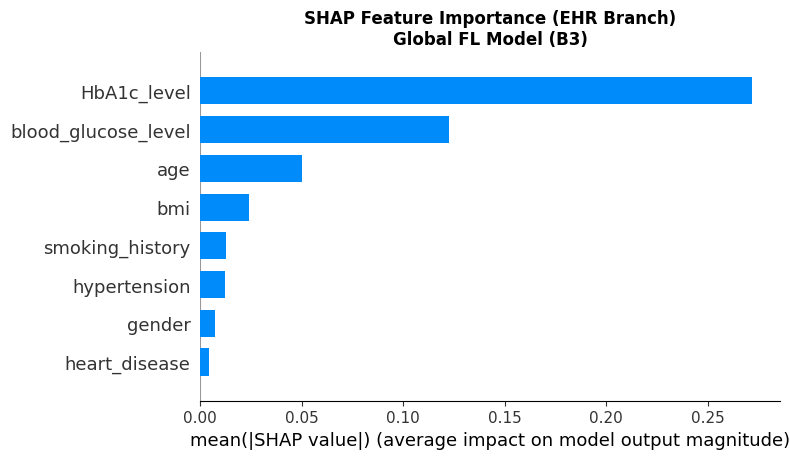

  ✓ Saved: /content/drive/MyDrive/MULTIMODAL/xai_results_b3/shap_feature_importance_bar.png


In [15]:
print("\n" + "=" * 60)
print("STEP 4: SHAP VISUALIZATIONS")
print("=" * 60)

# Prepare data for visualization
test_features_np = test_tensor.cpu().numpy()

print("\n[1/4] Creating Global Feature Importance Bar Plot...")

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    features=test_features_np,
    feature_names=FEATURE_NAMES,
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance (EHR Branch)\nGlobal FL Model (B3)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{config.SAVE_DIR}/shap_feature_importance_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"  ✓ Saved: {config.SAVE_DIR}/shap_feature_importance_bar.png")

# **18: SHAP Beeswarm Plot**


[2/4] Creating Beeswarm Plot...


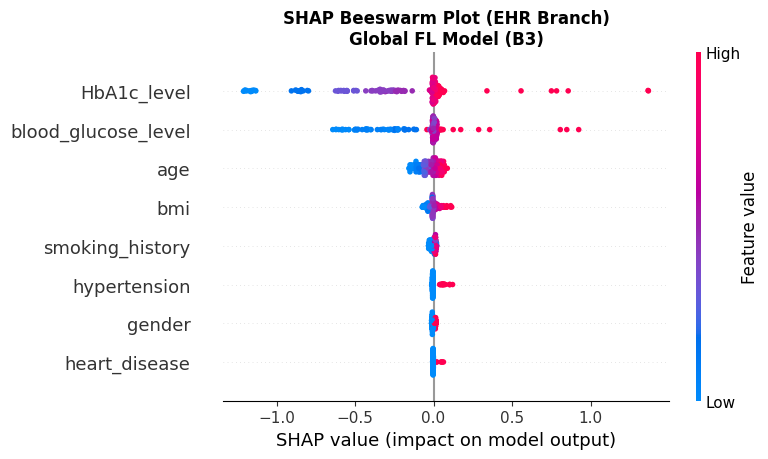

  ✓ Saved: /content/drive/MyDrive/MULTIMODAL/xai_results_b3/shap_beeswarm.png


In [16]:
print("\n[2/4] Creating Beeswarm Plot...")

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    features=test_features_np,
    feature_names=FEATURE_NAMES,
    show=False
)
plt.title("SHAP Beeswarm Plot (EHR Branch)\nGlobal FL Model (B3)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{config.SAVE_DIR}/shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"  ✓ Saved: {config.SAVE_DIR}/shap_beeswarm.png")

# **19: SHAP Force Plots - Setup**

In [17]:
print("\n[3/4] Creating Force Plots for Individual Patients...")

# Get expected value
if hasattr(explainer, 'expected_value'):
    expected_value = explainer.expected_value
    if isinstance(expected_value, (list, np.ndarray)):
        expected_value = float(expected_value[0]) if len(expected_value) > 0 else 0.5
    elif torch.is_tensor(expected_value):
        expected_value = expected_value.item()
else:
    expected_value = 0.5

print(f"  Expected value (base prediction): {expected_value:.4f}")

# Find examples for visualization
# Get predictions
with torch.no_grad():
    preds = ehr_wrapper(test_tensor).cpu().numpy().ravel()

# Find diabetic (high prob) and non-diabetic (low prob) examples
diabetic_mask = (y_test_shap == 1) & (preds > 0.7)
non_diabetic_mask = (y_test_shap == 0) & (preds < 0.3)

diabetic_indices = np.where(diabetic_mask)[0]
non_diabetic_indices = np.where(non_diabetic_mask)[0]

print(f"  High-confidence diabetic cases: {len(diabetic_indices)}")
print(f"  High-confidence non-diabetic cases: {len(non_diabetic_indices)}")


[3/4] Creating Force Plots for Individual Patients...
  Expected value (base prediction): 0.5566
  High-confidence diabetic cases: 13
  High-confidence non-diabetic cases: 140


# **20: SHAP Force Plot - Diabetic Case**


  Diabetic case (index 50):
    Prediction: 1.0000
    True label: 1


<Figure size 1200x300 with 0 Axes>

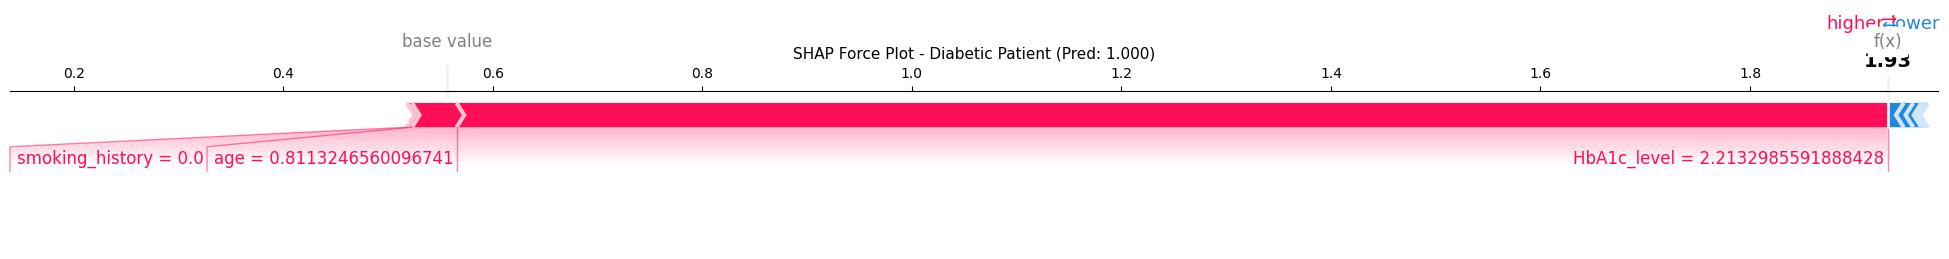

    ✓ Saved: /content/drive/MyDrive/MULTIMODAL/xai_results_b3/shap_force_diabetic.png


In [18]:
if len(diabetic_indices) > 0:
    idx = diabetic_indices[0]
    print(f"\n  Diabetic case (index {idx}):")
    print(f"    Prediction: {preds[idx]:.4f}")
    print(f"    True label: {int(y_test_shap[idx])}")

    plt.figure(figsize=(12, 3))
    shap.force_plot(
        expected_value,
        shap_values[idx],
        features=test_features_np[idx],
        feature_names=FEATURE_NAMES,
        matplotlib=True,
        show=False
    )
    plt.title(f"SHAP Force Plot - Diabetic Patient (Pred: {preds[idx]:.3f})", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{config.SAVE_DIR}/shap_force_diabetic.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"    ✓ Saved: {config.SAVE_DIR}/shap_force_diabetic.png")

# **21: SHAP Force Plot - Non-Diabetic Case**


  Non-diabetic case (index 2):
    Prediction: 0.2035
    True label: 0


<Figure size 1200x300 with 0 Axes>

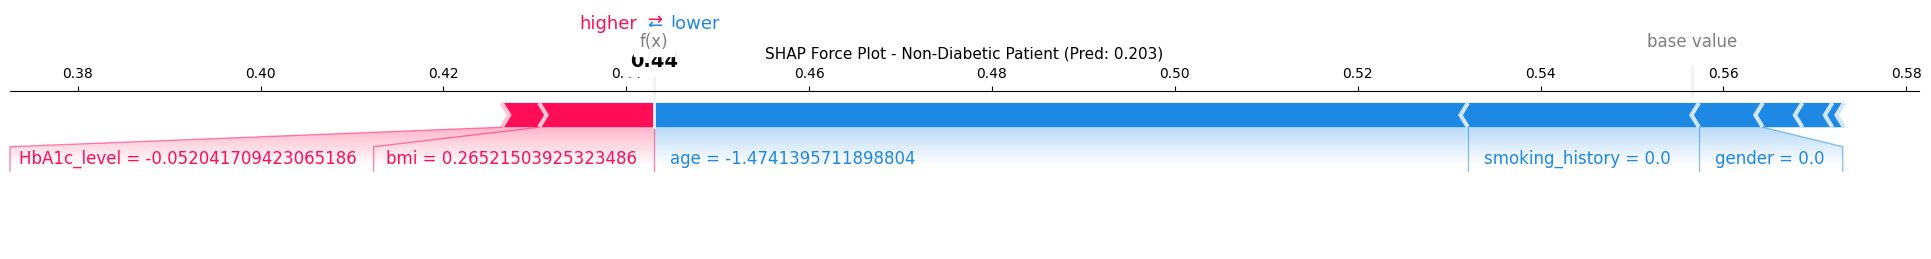

    ✓ Saved: /content/drive/MyDrive/MULTIMODAL/xai_results_b3/shap_force_non_diabetic.png


In [19]:
if len(non_diabetic_indices) > 0:
    idx = non_diabetic_indices[0]
    print(f"\n  Non-diabetic case (index {idx}):")
    print(f"    Prediction: {preds[idx]:.4f}")
    print(f"    True label: {int(y_test_shap[idx])}")

    plt.figure(figsize=(12, 3))
    shap.force_plot(
        expected_value,
        shap_values[idx],
        features=test_features_np[idx],
        feature_names=FEATURE_NAMES,
        matplotlib=True,
        show=False
    )
    plt.title(f"SHAP Force Plot - Non-Diabetic Patient (Pred: {preds[idx]:.3f})", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{config.SAVE_DIR}/shap_force_non_diabetic.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"    ✓ Saved: {config.SAVE_DIR}/shap_force_non_diabetic.png")

# **22: SHAP Feature Importance Summary Table**

In [20]:
print("\n[4/4] Creating Feature Importance Summary...")

# Calculate mean absolute SHAP values
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Create summary dataframe
feature_importance_df = pd.DataFrame({
    'Feature': FEATURE_NAMES,
    'Mean |SHAP|': mean_abs_shap,
    'Importance Rank': range(1, len(FEATURE_NAMES) + 1)
}).sort_values('Mean |SHAP|', ascending=False)

feature_importance_df['Importance Rank'] = range(1, len(FEATURE_NAMES) + 1)
feature_importance_df = feature_importance_df.reset_index(drop=True)

print("\nEHR Feature Importance Ranking:")
print("=" * 50)
for _, row in feature_importance_df.iterrows():
    print(f"  {int(row['Importance Rank']):2d}. {row['Feature']:<25s} {row['Mean |SHAP|']:.4f}")

# Save to CSV
feature_importance_df.to_csv(f"{config.SAVE_DIR}/shap_feature_importance.csv", index=False)
print(f"\n✓ Saved: {config.SAVE_DIR}/shap_feature_importance.csv")


[4/4] Creating Feature Importance Summary...

EHR Feature Importance Ranking:
   1. HbA1c_level               0.2720
   2. blood_glucose_level       0.1226
   3. age                       0.0501
   4. bmi                       0.0238
   5. smoking_history           0.0126
   6. hypertension              0.0119
   7. gender                    0.0072
   8. heart_disease             0.0042

✓ Saved: /content/drive/MyDrive/MULTIMODAL/xai_results_b3/shap_feature_importance.csv


# **23: SHAP Custom Bar Chart**

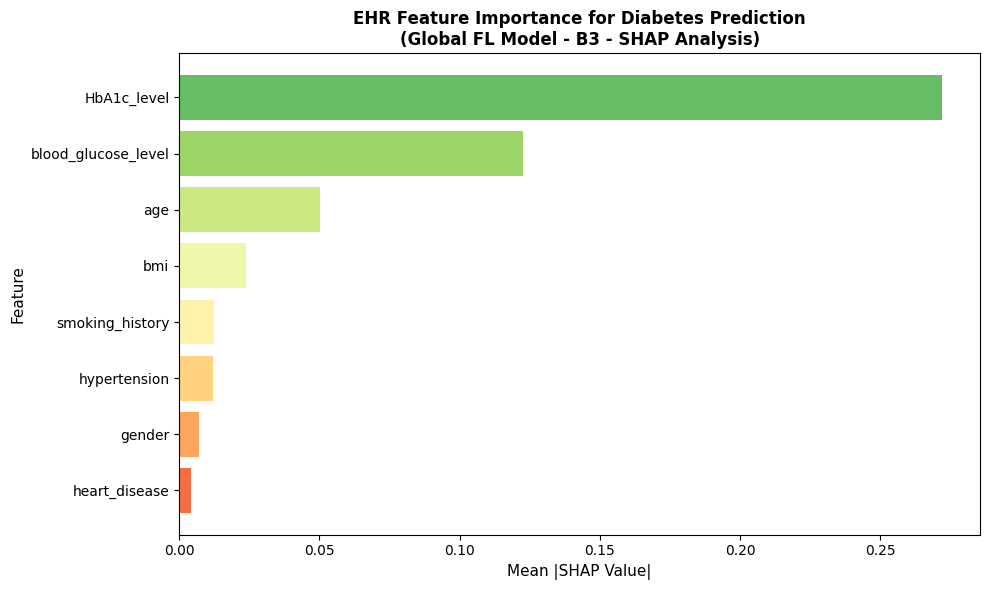

✓ Saved: /content/drive/MyDrive/MULTIMODAL/xai_results_b3/shap_importance_custom.png


In [21]:
plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(FEATURE_NAMES)))
bars = plt.barh(
    feature_importance_df['Feature'][::-1],
    feature_importance_df['Mean |SHAP|'][::-1],
    color=colors[::-1]
)
plt.xlabel('Mean |SHAP Value|', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.title('EHR Feature Importance for Diabetes Prediction\n(Global FL Model - B3 - SHAP Analysis)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{config.SAVE_DIR}/shap_importance_custom.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {config.SAVE_DIR}/shap_importance_custom.png")

# **24: Define Retinal Dataset for Grad-CAM**

In [22]:
print("\n" + "=" * 60)
print("STEP 5: LOADING RETINAL DATA FOR GRAD-CAM (B3)")
print("=" * 60)

def get_val_test_transform(image_size=300):
    return transforms.Compose([
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])


class CachedRetinalDataset(Dataset):
    """Dataset that loads preprocessed images from cache."""

    def __init__(self, df, cache_dir, is_training=False, image_size=300):
        self.df = df.reset_index(drop=True)
        self.cache_dir = Path(cache_dir)
        self.size = image_size
        self.transform = get_val_test_transform(image_size)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_name = row['image']
        label = float(row['patient_label'])

        cache_path = self.cache_dir / f"{image_name}.npy"

        try:
            img = np.load(cache_path)
            img_raw = img.copy()  # Keep raw for visualization
            img = img.astype(np.float32) / 255.0
            img = torch.from_numpy(img).permute(2, 0, 1)
        except:
            img = torch.zeros(3, self.size, self.size)
            img_raw = np.zeros((self.size, self.size, 3), dtype=np.uint8)

        img_normalized = self.transform(img)

        return {
            'image': img_normalized,
            'image_raw': img_raw,  # For visualization
            'label': torch.tensor(label, dtype=torch.float32),
            'image_name': image_name
        }

print("✓ CachedRetinalDataset defined")


STEP 5: LOADING RETINAL DATA FOR GRAD-CAM (B3)
✓ CachedRetinalDataset defined


# **25: Load Retinal Test Data**

In [23]:
ret_splits_dir = Path(config.RETINAL_SPLITS_DIR)
ret_cache_dir = Path(config.RETINAL_CACHE_DIR)

ret_test_df = pd.read_csv(ret_splits_dir / "retinal_test_images.csv")

ret_test_ds = CachedRetinalDataset(
    ret_test_df,
    cache_dir=ret_cache_dir / "test",
    is_training=False,
    image_size=config.IMAGE_SIZE
)

ret_test_loader = DataLoader(
    ret_test_ds,
    batch_size=1,  # One at a time for Grad-CAM
    shuffle=False,
    num_workers=0
)

print(f"\nRetinal test data loaded (B3 @ {config.IMAGE_SIZE}×{config.IMAGE_SIZE}):")
print(f"  Test images: {len(ret_test_df):,}")
print(f"  Cache directory: {ret_cache_dir / 'test'}")


Retinal test data loaded (B3 @ 300×300):
  Test images: 5,266
  Cache directory: /content/drive/MyDrive/MULTIMODAL/datasets/EYEPACS/preprocessed_cache_300/test


# **26: Create Grad-CAM Wrapper**

In [24]:
print("\n" + "=" * 60)
print("STEP 6: GRAD-CAM SETUP (EfficientNet-B3)")
print("=" * 60)

class RetinalGradCAMWrapper(nn.Module):
    """Wrapper for Grad-CAM on the retinal branch."""

    def __init__(self, global_model):
        super().__init__()
        self.encoder = global_model.ret_encoder
        self.ehr_dim = global_model.ehr_dim
        self.img_dim = global_model.img_dim
        self.classifier = global_model.classifier

    def forward(self, x):
        # Get image features
        img_feats = self.encoder(x)
        # Pad with zeros for EHR
        ehr_zero = x.new_zeros(x.size(0), self.ehr_dim)
        fused = torch.cat([ehr_zero, img_feats], dim=1)
        return self.classifier(fused)


retinal_wrapper = RetinalGradCAMWrapper(global_model).to(device)
retinal_wrapper.eval()

print("✓ RetinalGradCAMWrapper created")


STEP 6: GRAD-CAM SETUP (EfficientNet-B3)
✓ RetinalGradCAMWrapper created


# **27: Setup Grad-CAM Target Layer**

In [27]:
# Identify target layer for Grad-CAM (B3)
# NOTE: We don't create cam_extractor here - we'll do it AFTER getting predictions
# This avoids conflict between GradCAM hooks and torch.no_grad()

target_layer = retinal_wrapper.encoder.features[-1]

print(f"Target layer for Grad-CAM: {type(target_layer).__name__}")
print("✓ Target layer identified")
print("\nNote: GradCAM extractor will be created after predictions to avoid hook conflicts")

Target layer for Grad-CAM: Conv2dNormActivation
✓ Target layer identified

Note: GradCAM extractor will be created after predictions to avoid hook conflicts


# **28: Get Predictions for All Test Images**

In [29]:
print("\n" + "=" * 60)
print("STEP 7: GETTING PREDICTIONS FOR ALL TEST IMAGES")
print("=" * 60)

def denormalize_image(img_tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """Denormalize image tensor for visualization."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    img = torch.clamp(img, 0, 1)
    return img

print("\nGetting predictions for all test images...")
print("(Running without GradCAM hooks for efficiency)")

all_results = []
retinal_wrapper.eval()

# Use torch.no_grad() for efficient prediction
# GradCAM will be applied later only to selected examples
with torch.no_grad():
    for batch in tqdm(ret_test_loader, desc="Predicting"):
        image = batch['image'].to(device)
        label = batch['label'].item()
        image_name = batch['image_name'][0]
        image_raw = batch['image_raw'][0].numpy()

        # Skip NaN images
        if torch.isnan(image).any() or torch.isinf(image).any():
            continue

        # Forward pass
        logits = retinal_wrapper(image)
        prob = torch.sigmoid(logits).item()

        pred = 1 if prob >= 0.5 else 0

        all_results.append({
            'image_name': image_name,
            'label': int(label),
            'prob': prob,
            'pred': pred,
            'correct': pred == int(label),
            'image_raw': image_raw,
            'image_tensor': batch['image'][0].clone()
        })

# Convert to DataFrame for analysis
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['image_raw', 'image_tensor']}
    for r in all_results
])

print(f"\nPrediction summary:")
print(f"  Total images: {len(results_df)}")
print(f"  Correct: {results_df['correct'].sum()} ({100*results_df['correct'].mean():.1f}%)")
print(f"  Accuracy: {100*results_df['correct'].mean():.1f}%")


STEP 7: GETTING PREDICTIONS FOR ALL TEST IMAGES

Getting predictions for all test images...
(Running without GradCAM hooks for efficiency)


Predicting:   0%|          | 0/5266 [00:00<?, ?it/s]


RuntimeError: cannot register a hook on a tensor that doesn't require gradient

# **29: Select Examples for Visualization**

In [ ]:
# Select examples for visualization
# True Positive: label=1, pred=1, high confidence
tp_mask = (results_df['label'] == 1) & (results_df['pred'] == 1) & (results_df['prob'] > 0.7)

# True Negative: label=0, pred=0, low confidence
tn_mask = (results_df['label'] == 0) & (results_df['pred'] == 0) & (results_df['prob'] < 0.3)

# False Positive: label=0, pred=1
fp_mask = (results_df['label'] == 0) & (results_df['pred'] == 1)

# False Negative: label=1, pred=0
fn_mask = (results_df['label'] == 1) & (results_df['pred'] == 0)

tp_indices = results_df[tp_mask].index.tolist()[:3]
tn_indices = results_df[tn_mask].index.tolist()[:3]
fp_indices = results_df[fp_mask].index.tolist()[:3]
fn_indices = results_df[fn_mask].index.tolist()[:3]

print(f"\nSelected examples:")
print(f"  True Positives: {len(tp_indices)}")
print(f"  True Negatives: {len(tn_indices)}")
print(f"  False Positives: {len(fp_indices)}")
print(f"  False Negatives: {len(fn_indices)}")

# **30: Define Grad-CAM Visualization Function**

In [ ]:
print("\n" + "=" * 60)
print("STEP 8: VISUALIZING GRAD-CAM RESULTS (B3)")
print("=" * 60)

def visualize_gradcam_single(result, cam_extractor, model, device, save_path=None):
    """Visualize Grad-CAM for a single image."""

    # Get image and prepare
    image_tensor = result['image_tensor'].clone()
    image_raw = result['image_raw']

    # Generate Grad-CAM
    model.eval()
    image_input = image_tensor.unsqueeze(0).to(device)
    image_input.requires_grad_(True)

    # Forward pass
    output = model(image_input)

    # Get CAM (torchcam handles backward internally)
    cams = cam_extractor(class_idx=0, scores=output)
    cam = cams[0].squeeze().cpu().numpy()

    # Compute probability
    prob = torch.sigmoid(output).detach().item()

    # Resize CAM to image size
    import cv2
    cam_resized = cv2.resize(cam, (config.IMAGE_SIZE, config.IMAGE_SIZE))
    cam_resized = (cam_resized - cam_resized.min()) / (cam_resized.max() - cam_resized.min() + 1e-8)

    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # Original image
    axes[0].imshow(image_raw)
    axes[0].set_title('Original Image', fontsize=10)
    axes[0].axis('off')

    # Grad-CAM heatmap
    im = axes[1].imshow(cam_resized, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap', fontsize=10)
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    # Overlay
    overlay = image_raw.copy().astype(np.float32) / 255.0
    heatmap = plt.cm.jet(cam_resized)[:, :, :3]
    overlaid = 0.6 * overlay + 0.4 * heatmap
    overlaid = np.clip(overlaid, 0, 1)

    axes[2].imshow(overlaid)
    axes[2].set_title('Overlay', fontsize=10)
    axes[2].axis('off')

    # Add info
    label_str = "DR" if result['label'] == 1 else "No DR"
    pred_str = "DR" if result['pred'] == 1 else "No DR"
    correct_str = "✓" if result['correct'] else "✗"

    fig.suptitle(
        f"True: {label_str} | Pred: {pred_str} ({prob:.3f}) {correct_str}",
        fontsize=11, fontweight='bold'
    )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()

    return cam_resized

print("✓ visualize_gradcam_single function defined")

# **31: Visualize True Positives**

In [ ]:
print("\n[1/4] True Positives (Correctly identified DR):")
for i, idx in enumerate(tp_indices):
    result = all_results[idx]
    print(f"  Processing TP example {i+1}...")
    visualize_gradcam_single(
        result, cam_extractor, retinal_wrapper, device,
        save_path=f"{config.SAVE_DIR}/gradcam_tp_{i+1}.png"
    )

# **32: Visualize True Negatives**

In [ ]:
print("\n[2/4] True Negatives (Correctly identified No DR):")
for i, idx in enumerate(tn_indices):
    result = all_results[idx]
    print(f"  Processing TN example {i+1}...")
    visualize_gradcam_single(
        result, cam_extractor, retinal_wrapper, device,
        save_path=f"{config.SAVE_DIR}/gradcam_tn_{i+1}.png"
    )

# **33: Visualize False Positives**

In [ ]:
print("\n[3/4] False Positives (Incorrectly predicted DR):")
for i, idx in enumerate(fp_indices):
    result = all_results[idx]
    print(f"  Processing FP example {i+1}...")
    visualize_gradcam_single(
        result, cam_extractor, retinal_wrapper, device,
        save_path=f"{config.SAVE_DIR}/gradcam_fp_{i+1}.png"
    )

# **34: Visualize False Negatives**

In [ ]:
print("\n[4/4] False Negatives (Missed DR cases):")
for i, idx in enumerate(fn_indices):
    result = all_results[idx]
    print(f"  Processing FN example {i+1}...")
    visualize_gradcam_single(
        result, cam_extractor, retinal_wrapper, device,
        save_path=f"{config.SAVE_DIR}/gradcam_fn_{i+1}.png"
    )

# **35: Define Grad-CAM Grid Function**

In [ ]:
print("\n" + "=" * 60)
print("STEP 9: CREATING GRAD-CAM SUMMARY GRID (B3)")
print("=" * 60)

def create_gradcam_grid(results_list, cam_extractor, model, device, title, save_path):
    """Create a grid of Grad-CAM visualizations."""

    n_examples = len(results_list)
    if n_examples == 0:
        print(f"  No examples for {title}")
        return

    fig, axes = plt.subplots(n_examples, 3, figsize=(12, 4 * n_examples))

    if n_examples == 1:
        axes = axes.reshape(1, -1)

    for i, result in enumerate(results_list):
        # Get image
        image_tensor = result['image_tensor'].clone()
        image_raw = result['image_raw']

        # Generate Grad-CAM
        model.eval()
        image_input = image_tensor.unsqueeze(0).to(device)
        image_input.requires_grad_(True)

        output = model(image_input)
        prob = torch.sigmoid(output).detach().item()

        # Get CAM
        cams = cam_extractor(class_idx=0, scores=output)
        cam = cams[0].squeeze().cpu().numpy()

        # Resize CAM
        import cv2
        cam_resized = cv2.resize(cam, (config.IMAGE_SIZE, config.IMAGE_SIZE))
        cam_resized = (cam_resized - cam_resized.min()) / (cam_resized.max() - cam_resized.min() + 1e-8)

        # Original
        axes[i, 0].imshow(image_raw)
        axes[i, 0].set_title(f"Original (Label: {'DR' if result['label']==1 else 'No DR'})", fontsize=9)
        axes[i, 0].axis('off')

        # Heatmap
        axes[i, 1].imshow(cam_resized, cmap='jet')
        axes[i, 1].set_title(f"Grad-CAM (Pred: {prob:.3f})", fontsize=9)
        axes[i, 1].axis('off')

        # Overlay
        overlay = image_raw.copy().astype(np.float32) / 255.0
        heatmap = plt.cm.jet(cam_resized)[:, :, :3]
        overlaid = 0.6 * overlay + 0.4 * heatmap
        overlaid = np.clip(overlaid, 0, 1)

        axes[i, 2].imshow(overlaid)
        axes[i, 2].set_title("Overlay", fontsize=9)
        axes[i, 2].axis('off')

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  ✓ Saved: {save_path}")

print("✓ create_gradcam_grid function defined")

# **36: Create Grad-CAM Summary Grids**

In [ ]:
print("\nCreating summary grids...")

# True Positives Grid
if tp_indices:
    tp_results = [all_results[idx] for idx in tp_indices[:4]]
    create_gradcam_grid(
        tp_results, cam_extractor, retinal_wrapper, device,
        "Grad-CAM: True Positives (Correctly Identified DR) - B3",
        f"{config.SAVE_DIR}/gradcam_grid_tp.png"
    )

# True Negatives Grid
if tn_indices:
    tn_results = [all_results[idx] for idx in tn_indices[:4]]
    create_gradcam_grid(
        tn_results, cam_extractor, retinal_wrapper, device,
        "Grad-CAM: True Negatives (Correctly Identified No DR) - B3",
        f"{config.SAVE_DIR}/gradcam_grid_tn.png"
    )

# Misclassifications Grid
misc_indices = fp_indices[:2] + fn_indices[:2]
if misc_indices:
    misc_results = [all_results[idx] for idx in misc_indices]
    create_gradcam_grid(
        misc_results, cam_extractor, retinal_wrapper, device,
        "Grad-CAM: Misclassifications (FP & FN) - B3",
        f"{config.SAVE_DIR}/gradcam_grid_misclassified.png"
    )

# **37: Create Combined XAI Summary Figure**

In [ ]:
print("\n" + "=" * 60)
print("STEP 10: COMBINED XAI SUMMARY (B3)")
print("=" * 60)

# Create a combined summary figure
fig = plt.figure(figsize=(16, 10))

# Left side: SHAP Feature Importance
ax1 = fig.add_subplot(1, 2, 1)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(FEATURE_NAMES)))
bars = ax1.barh(
    feature_importance_df['Feature'][::-1],
    feature_importance_df['Mean |SHAP|'][::-1],
    color=colors[::-1]
)
ax1.set_xlabel('Mean |SHAP Value|', fontsize=11)
ax1.set_ylabel('Feature', fontsize=11)
ax1.set_title('EHR Branch: Feature Importance (SHAP)\n', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Right side: Sample Grad-CAM
ax2 = fig.add_subplot(1, 2, 2)

# Get a sample Grad-CAM image
if tp_indices:
    sample_result = all_results[tp_indices[0]]
    image_raw = sample_result['image_raw']

    # Generate CAM
    image_tensor = sample_result['image_tensor'].clone()
    image_input = image_tensor.unsqueeze(0).to(device)
    image_input.requires_grad_(True)

    output = retinal_wrapper(image_input)
    prob = torch.sigmoid(output).detach().item()

    cams = cam_extractor(class_idx=0, scores=output)
    cam = cams[0].squeeze().cpu().numpy()

    import cv2
    cam_resized = cv2.resize(cam, (config.IMAGE_SIZE, config.IMAGE_SIZE))
    cam_resized = (cam_resized - cam_resized.min()) / (cam_resized.max() - cam_resized.min() + 1e-8)

    # Overlay
    overlay = image_raw.copy().astype(np.float32) / 255.0
    heatmap = plt.cm.jet(cam_resized)[:, :, :3]
    overlaid = 0.6 * overlay + 0.4 * heatmap
    overlaid = np.clip(overlaid, 0, 1)

    ax2.imshow(overlaid)
    ax2.set_title(f'Retinal Branch: Grad-CAM Visualization (B3)\n(DR case, Pred: {prob:.3f})',
                  fontsize=12, fontweight='bold')
    ax2.axis('off')
else:
    ax2.text(0.5, 0.5, 'No sample available', ha='center', va='center')
    ax2.axis('off')

fig.suptitle('Explainable AI for Multimodal Federated Learning\nDiabetes Detection System (EfficientNet-B3)',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(f"{config.SAVE_DIR}/xai_combined_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {config.SAVE_DIR}/xai_combined_summary.png")

# **38: Save SHAP Results**

In [ ]:
print("\n" + "=" * 60)
print("STEP 11: SAVING XAI RESULTS (B3)")
print("=" * 60)

# Save SHAP values
shap_results = {
    'feature_names': FEATURE_NAMES,
    'shap_values': shap_values,
    'test_features': test_features_np,
    'test_labels': y_test_shap,
    'feature_importance': feature_importance_df.to_dict(),
    'expected_value': float(expected_value)
}

np.save(f"{config.SAVE_DIR}/shap_results.npy", shap_results, allow_pickle=True)
print(f"✓ SHAP results saved to: {config.SAVE_DIR}/shap_results.npy")

# **39: Save Grad-CAM Summary**

In [ ]:
# Save Grad-CAM summary
gradcam_summary = {
    'model': 'EfficientNet-B3',
    'image_size': config.IMAGE_SIZE,
    'total_images': len(results_df),
    'accuracy': float(results_df['correct'].mean()),
    'true_positives': len(tp_indices),
    'true_negatives': len(tn_indices),
    'false_positives': len(fp_indices),
    'false_negatives': len(fn_indices),
    'examples': {
        'tp_indices': tp_indices,
        'tn_indices': tn_indices,
        'fp_indices': fp_indices,
        'fn_indices': fn_indices
    }
}

import json
with open(f"{config.SAVE_DIR}/gradcam_summary.json", 'w') as f:
    json.dump(gradcam_summary, f, indent=2)
print(f"✓ Grad-CAM summary saved to: {config.SAVE_DIR}/gradcam_summary.json")

# **40: List All Saved Files**

In [ ]:
print("\nAll saved files:")
for f in sorted(os.listdir(config.SAVE_DIR)):
    filepath = os.path.join(config.SAVE_DIR, f)
    size = os.path.getsize(filepath) / 1024  # KB
    print(f"  {f:<45s} {size:>8.1f} KB")

# **41: Final Summary Report**

In [ ]:
print("\n" + "=" * 70)
print("XAI ANALYSIS SUMMARY (EfficientNet-B3)")
print("=" * 70)

print(f"""
Explainable AI Analysis Complete!
────────────────────────────────────────────────────────────

SHAP Analysis (EHR Branch)
─────────────────────────
Samples analyzed:       {config.SHAP_TEST_SAMPLES}
Background samples:     {config.SHAP_BACKGROUND_SAMPLES}

Top 5 Important Features:

""")

for i, (_, row) in enumerate(feature_importance_df.head(5).iterrows()):
    print(f"  {i+1}. {row['Feature']:<25s} (|SHAP|: {row['Mean |SHAP|']:.4f})")

print(f"""

Plots generated:
  • Feature importance bar chart
  • Beeswarm plot
  • Force plots (diabetic & non-diabetic cases)

Grad-CAM Analysis (Retinal Branch - EfficientNet-B3)
──────────────────────────────────────────────────────
Model:                  EfficientNet-B3
Image size:             {config.IMAGE_SIZE}×{config.IMAGE_SIZE}
Test images analyzed:   {len(results_df)}
Accuracy:               {100*results_df['correct'].mean():.1f}%

Examples visualized:
  • True Positives:  {len(tp_indices)} (correctly identified DR)
  • True Negatives:  {len(tn_indices)} (correctly identified No DR)
  • False Positives: {len(fp_indices)} (incorrectly predicted DR)
  • False Negatives: {len(fn_indices)} (missed DR cases)

Output Files
─────────────
Save directory: {config.SAVE_DIR}

Key files:
  • shap_feature_importance.csv
  • shap_feature_importance_bar.png
  • shap_beeswarm.png
  • shap_force_diabetic.png
  • shap_force_non_diabetic.png
  • gradcam_grid_tp.png
  • gradcam_grid_tn.png
  • gradcam_grid_misclassified.png
  • xai_combined_summary.png
────────────────────────────────────────────────────────────

Clinical Interpretation:
────────────────────────
EHR Branch:
  The SHAP analysis reveals which clinical features most strongly
  influence the model's diabetes predictions. Features like blood
  glucose level, HbA1c, and BMI typically show high importance,
  consistent with clinical diabetes indicators.

Retinal Branch (EfficientNet-B3 @ 300×300):
  Grad-CAM visualizations highlight regions of the fundus image
  that the model focuses on when predicting DR. In true positive
  cases, these regions often correspond to known pathological
  features (microaneurysms, exudates, hemorrhages).

  The B3 model at 300×300 resolution provides more detailed
  spatial attention maps compared to smaller variants, potentially
  capturing finer retinal pathologies.

This XAI analysis supports the interpretability goals outlined
in the project's review of multimodal FL for diabetes detection.

────────────────────────────────────────────────────────────
✓ XAI ANALYSIS COMPLETE (EfficientNet-B3)
────────────────────────────────────────────────────────────
""")

# **42: Cleanup**

In [ ]:
# Clear Grad-CAM hooks
cam_extractor.remove_hooks()

# Clear GPU memory
if device.type == 'cuda':
    torch.cuda.empty_cache()

print("✓ Cleanup complete")
print("\nXAI notebook execution finished successfully!")
print(f"\nAll results saved to: {config.SAVE_DIR}")